# **FOREWORD**

This notebook is an adaptation from the public work [here](https://www.kaggle.com/code/raddar/ncaa2025) for the past year's competition. <br>

This is updated for stage-2 submissions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import statsmodels.api as sm
import tqdm

from sklearn.metrics import *
import xgboost as xgb
from scipy.interpolate import UnivariateSpline

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)

In [2]:
data_dir       = "/kaggle/input/competitions/march-machine-learning-mania-2026"
sub_file_path  = f"{data_dir}/SampleSubmissionStage2.csv"
calibration_t  = 25
prob_cutoff    = (0.02, 0.98)

# **DATA LOAD**

In [3]:

# W -> women's basketball, M -> men's basketball
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

season = 2003  # change if you want different cutoff year for your models
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]


print(f"---> Data load complete")

---> Data load complete


# **EDA**

Let's take one random team and see its journey during the chosen season

In [4]:

season = 2025
teamid = 3163

r = regular_results.loc[
    (regular_results["Season"] == season)
    & ((regular_results["WTeamID"] == teamid) | (regular_results["LTeamID"] == teamid))
]
t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & ((tourney_results["WTeamID"] == teamid) | (tourney_results["LTeamID"] == teamid))
]
r["win"] = np.where(r["WTeamID"] == teamid, "win", "lose")
t["win"] = np.where(t["WTeamID"] == teamid, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
rt[["DayNum", "WScore", "LScore", "type", "win"]]

,DayNum,WScore,LScore,type,win
76407,3,86,32,regular season,win
76534,6,86,49,regular season,win
76747,11,69,58,regular season,win
76942,16,85,41,regular season,win
77170,21,71,52,regular season,win
77238,23,73,60,regular season,win
77508,29,88,52,regular season,win
77651,33,85,52,regular season,win
77814,38,79,68,regular season,lose
77874,41,79,44,regular season,win


In [5]:
# structure of seeds by division
s = W_seeds.loc[W_seeds["Season"] == 2015]
[s.loc[s["Seed"].str.startswith(d)] for d in ("X", "Y", "Z", "W")]

[      Season Seed  TeamID
 1104    2015  X01    3268
 1105    2015  X02    3397
 1106    2015  X03    3333
 1107    2015  X04    3181
 1108    2015  X05    3280
 1109    2015  X06    3203
 1110    2015  X07    3151
 1111    2015  X08    3343
 1112    2015  X09    3453
 1113    2015  X10    3338
 1114    2015  X11    3211
 1115    2015  X12    3408
 1116    2015  X13    3107
 1117    2015  X14    3355
 1118    2015  X15    3129
 1119    2015  X16    3308,
       Season Seed  TeamID
 1120    2015  Y01    3376
 1121    2015  Y02    3199
 1122    2015  Y03    3113
 1123    2015  Y04    3314
 1124    2015  Y05    3326
 1125    2015  Y06    3401
 1126    2015  Y07    3195
 1127    2015  Y08    3393
 1128    2015  Y09    3304
 1129    2015  Y10    3329
 1130    2015  Y11    3114
 1131    2015  Y12    3241
 1132    2015  Y13    3251
 1133    2015  Y14    3325
 1134    2015  Y15    3106
 1135    2015  Y16    3366,
       Season Seed  TeamID
 1136    2015  Z01    3323
 1137    2015  Z02    3124

In [6]:
# let's see what seed our previous example team had
seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == teamid)]

,Season,Seed,TeamID
1729,2025,Z02,3163


# **DATA PREPARATION**

Double the dataset with swapped team positions in box scores

In [7]:

def prepare_data(df):
    df = df[
    ["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
     "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
     "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"
    ]
    ]
    

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

Let's take an example match to double check if the same match is entered correctly in our dataset

In [8]:

season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
118444,2025,120,1182,62.0,1433,71.0,0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,9.0,1,1
329248,2025,120,1433,71.0,1182,62.0,0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,-9.0,0,1


## **EASY FEATURES**

In [9]:
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))

seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


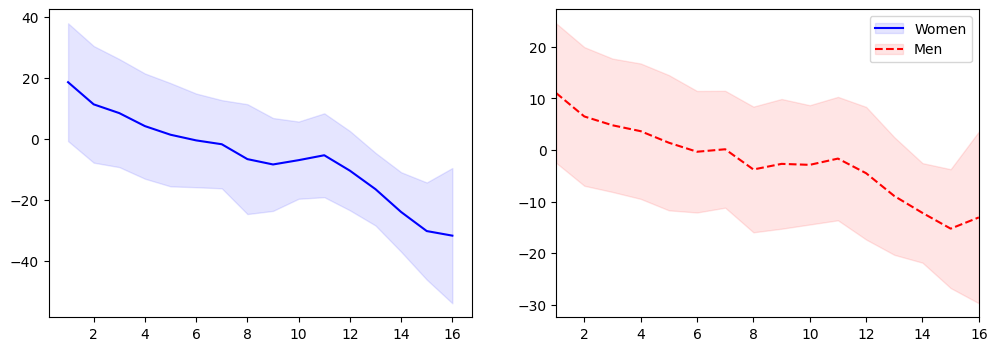

In [10]:
# let's see if __seed__ is predictive for predicting the point difference

tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

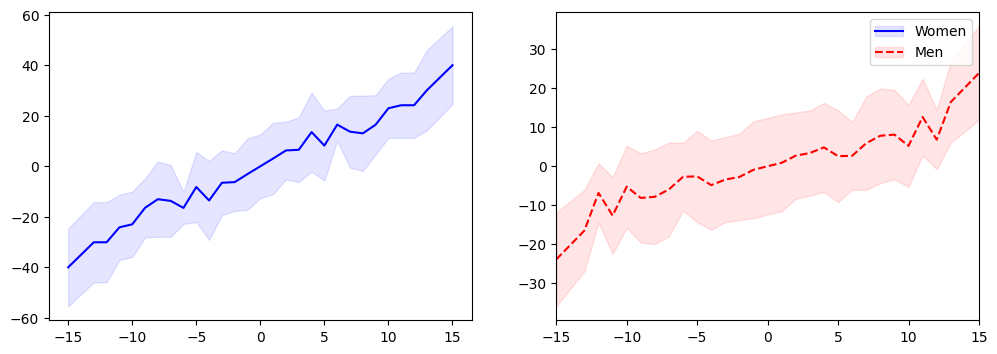

In [11]:
# let's see __seed difference__ is predictive for predicting the point difference

tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

## **MEDIUM DIFFICULTY FEATURES**

In [12]:
# box score columns, for which we want features to our model
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,16.903704,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370

## **HARD FEATURES**

In [13]:
def update_elo(winner_elo, loser_elo):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

base_elo  = 1000
elo_width = 400
k_factor  = 100

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
    
elos = pd.concat(elos)

elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"].values - tourney_data["T2_elo"].values

Let's merge the ELO and tourney data and proceed

<Axes: xlabel='elo'>

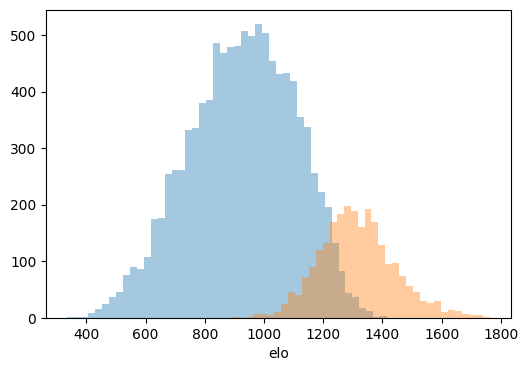

In [14]:
tmp = pd.merge(
    elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
    left_on = ['Season', 'TeamID'], 
    right_on = ['Season', 'T1_TeamID'],
    how = 'left'
)

plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

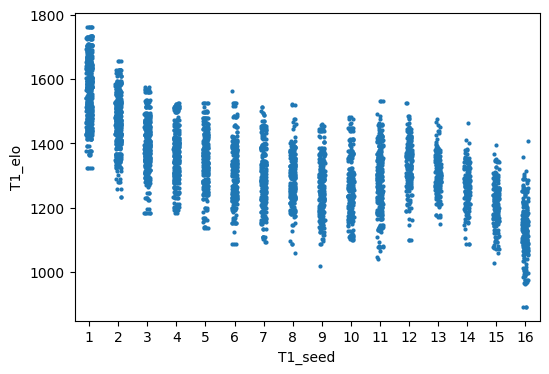

In [15]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

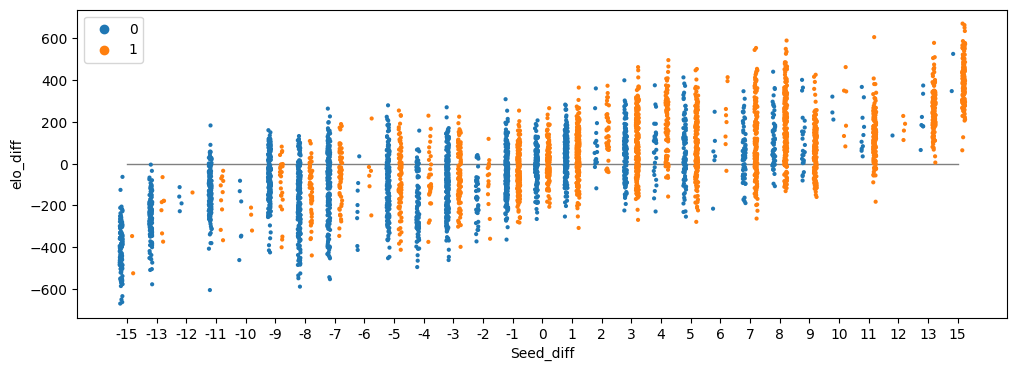

In [16]:
plt.figure(figsize=(12,4))
seaborn.stripplot(
    data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3
)
seaborn.lineplot([0]*29,color='gray',lw = 1)

## **HARDEST FEATURES**

In [17]:

regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])

# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"

seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]

tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")

tourney_data["diff_quality"] = tourney_data["T1_quality"].values - tourney_data["T2_quality"].values

100%|██████████| 22/22 [01:13<00:00,  3.36s/season]


QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


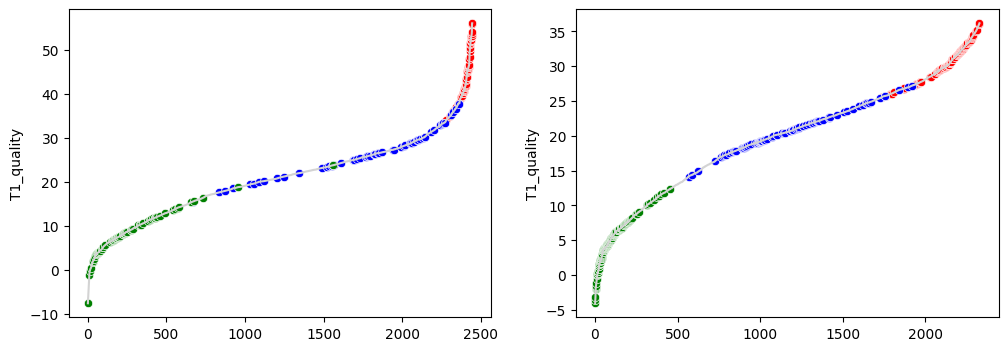

In [18]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])

tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)

pd.pivot_table(
    data=tmp, 
    index="T1_seed", 
    columns="QualitySeed", 
    values="men_women", 
    aggfunc="count"
).fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

In [19]:

print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


In [20]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


# **BASELINE MODEL**

In [21]:
features = [
    ### EASY FEATURES ###
    "men_women",    
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    #"T1_avg_FGM",
    "T1_avg_FGA",
    #"T1_avg_FGM3",
    #"T1_avg_FGA3",
    #"T1_avg_FTM",
    #"T1_avg_FTA",
    #"T1_avg_OR",
    #"T1_avg_DR",
    #"T1_avg_Ast",
    #"T1_avg_TO",
    #"T1_avg_Stl",
    "T1_avg_Blk",
    "T1_avg_PF",
    #"T1_avg_opponent_Score",
    #"T1_avg_opponent_FGM",
    "T1_avg_opponent_FGA",
    #"T1_avg_opponent_FGM3",
    #"T1_avg_opponent_FGA3",
    #"T1_avg_opponent_FTM",
    #"T1_avg_opponent_FTA",
    #"T1_avg_opponent_OR",
    #"T1_avg_opponent_DR",
    #"T1_avg_opponent_Ast",
    #"T1_avg_opponent_TO",
    #"T1_avg_opponent_Stl",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    #"T2_avg_FGM",
    "T2_avg_FGA",
    #"T2_avg_FGM3",
    #"T2_avg_FGA3",
    #"T2_avg_FTM",
    #"T2_avg_FTA",
    #"T2_avg_OR",
    #"T2_avg_DR",
    #"T2_avg_Ast",
    #"T2_avg_TO",
    #"T2_avg_Stl",
    "T2_avg_Blk",
    "T2_avg_PF",
    #"T2_avg_opponent_Score",
    #"T2_avg_opponent_FGM",
    "T2_avg_opponent_FGA",
    #"T2_avg_opponent_FGM3",
    #"T2_avg_opponent_FGA3",
    #"T2_avg_opponent_FTM",
    #"T2_avg_opponent_FTA",
    #"T2_avg_opponent_OR",
    #"T2_avg_opponent_DR",
    #"T2_avg_opponent_Ast",
    #"T2_avg_opponent_TO",
    #"T2_avg_opponent_Stl",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",    
    "elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
]

print(f"Number of features {len(features)}")

Number of features 25


In [22]:


param = {}
param["objective"]        = "reg:squarederror"
param["booster"]          = "gbtree"
param["eta"]              = 0.0075
param["subsample"]        = 0.6
param["colsample_bynode"] = 0.8
param["num_parallel_tree"] = 2
param["min_child_weight"]  = 4
param["max_depth"]         = 4
param["tree_method"]       = "hist"
param['grow_policy']       = 'lossguide'
param["max_bin"]           = 32

num_rounds = 1250

---> Season 2003 MAE: 8.84646433
---> Season 2004 MAE: 7.80829015
---> Season 2005 MAE: 7.70771038
---> Season 2006 MAE: 8.77056474
---> Season 2007 MAE: 7.62466196
---> Season 2008 MAE: 9.67733657
---> Season 2009 MAE: 9.41433911
---> Season 2010 MAE: 8.93682738
---> Season 2011 MAE: 9.92091691
---> Season 2012 MAE: 8.49168845
---> Season 2013 MAE: 9.67279145
---> Season 2014 MAE: 10.20280563
---> Season 2015 MAE: 7.94275949
---> Season 2016 MAE: 10.14263132
---> Season 2017 MAE: 9.94896868
---> Season 2018 MAE: 10.23849777
---> Season 2019 MAE: 9.11296957
---> Season 2021 MAE: 10.65154561
---> Season 2022 MAE: 10.68457563
---> Season 2023 MAE: 9.51566483
---> Season 2024 MAE: 9.53828494
---> Season 2025 MAE: 9.84201391
average mae: 9.30419585




<Axes: xlabel='pred_pointdiff', ylabel='average_win_pct'>

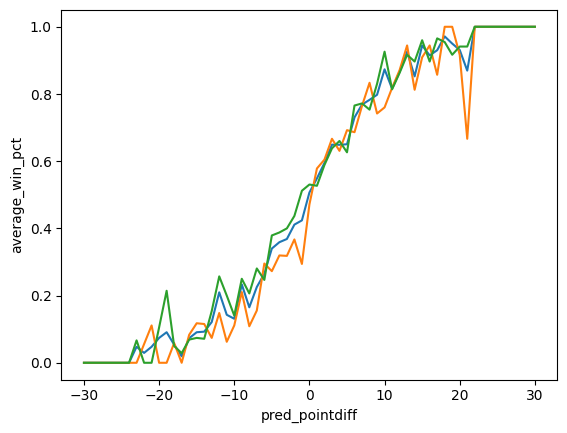

In [23]:

models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season out models
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)
    models[oof_season] = xgb.train(
        params=param,
        dtrain=dtrain,
        num_boost_round = num_rounds,        
    )
    preds = models[oof_season].predict(dval)
    print(f"---> Season {oof_season} MAE: {mean_absolute_error(y_val, preds) :,.8f}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)
    
print(f"average mae: {np.mean(oof_mae) :,.8f}\n\n")

df = pd.DataFrame(
    {"Season": oof_ss, 
     "pred": oof_preds, 
     "label": [(t > 0) * 1 for t in oof_targets], 
     "men_women": tourney_data["men_women"]
    }
)

df["pred_pointdiff"] = df["pred"].astype(int)

xdf_all = df.clip(-30, 30).groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_men = df.clip(-30, 30).loc[df["men_women"] == 0].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_women = df.clip(-30, 30).loc[df["men_women"] == 1].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")

seaborn.lineplot(x=xdf_all["pred_pointdiff"], y=xdf_all["average_win_pct"])
seaborn.lineplot(x=xdf_men["pred_pointdiff"], y=xdf_men["average_win_pct"])
seaborn.lineplot(x=xdf_women["pred_pointdiff"], y=xdf_women["average_win_pct"])




## **CALIBRATION**

---> Brier score =  0.16579571
2003 0.17951833
2004 0.16959541
2005 0.16509778
2006 0.19287821
2007 0.14152711
2008 0.15092345
2009 0.16717072
2010 0.16808056
2011 0.18475204
2012 0.15432833
2013 0.1685246
2014 0.17702749
2015 0.14388098
2016 0.17302362
2017 0.16079074
2018 0.17876751
2019 0.14222077
2021 0.18109752
2022 0.18947023
2023 0.18513803
2024 0.15636331
2025 0.12096311


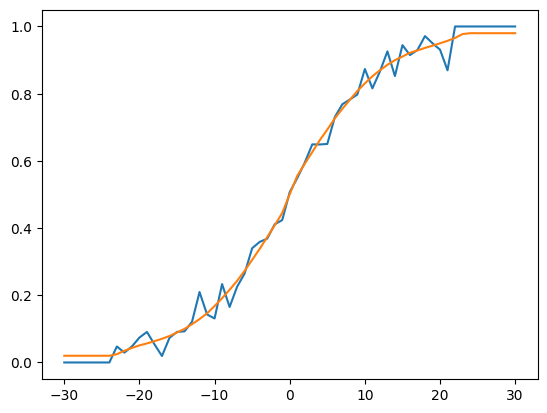

In [24]:

t   = calibration_t
dat = list(zip(oof_preds, np.array(oof_targets)>0))
dat = sorted(dat, key = lambda x: x[0])
pred, label  = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=5)

spline_fit   = np.clip(
    spline_model(np.clip(oof_preds, -t, t)), 
    prob_cutoff[0], 
    prob_cutoff[1],
)

print(f"---> Brier score =  {brier_score_loss(np.array(oof_targets)>0, spline_fit) :,.8f}")

df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_pointdiff')[['spline','label']].mean().reset_index()

plt.figure()
plt.plot(xdf['pred_pointdiff'],xdf['label'])
plt.plot(xdf['pred_pointdiff'],xdf['spline'])

for oof_season in set(tourney_data.Season):
    x = df.loc[df["Season"] == oof_season, "spline"].values
    y = df.loc[df["Season"] == oof_season, "label"].values
    
    print(oof_season, np.round(brier_score_loss(y, x),8))

# **SUBMISSION**

Please check when the stage 2 data will be made available and revisit this. Currently this is as of stage 1

In [25]:
X = pd.read_csv(sub_file_path)
display(X.head(5))

X['Season'] = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))
X['men_women'] = X['T1_TeamID'].apply(lambda t: 0 if str(t)[0]=='1' else 1)

X = pd.merge(X, ss_T1, on = ['Season', 'T1_TeamID'], how = 'left')
X = pd.merge(X, ss_T2, on = ['Season', 'T2_TeamID'], how = 'left')
X = pd.merge(X, seeds_T1, on = ['Season', 'T1_TeamID'], how = 'left')
X = pd.merge(X, seeds_T2, on = ['Season', 'T2_TeamID'], how = 'left')
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")

X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

preds = []
for oof_season in set(tourney_data.Season):
    dtest = xgb.DMatrix(X[features].values)
    margin_preds = models[oof_season].predict(dtest) * 1.0 
    probs = np.clip(
        spline_model(np.clip(margin_preds, -t, t)), 
        prob_cutoff[0], 
        prob_cutoff[1]
    )
    preds.append(probs)
    
X['Pred'] = np.array(preds).mean(axis=0) 

sub = X[['ID','Pred']]
sub.to_csv('submission.csv',index=None)

print(f"\n---> Submission file shape = {sub.shape}\n")

!head submission.csv

,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5



---> Submission file shape = (132133, 2)

ID,Pred
2026_1101_1102,0.9800000000000003
2026_1101_1103,0.9726381280928763
2026_1101_1104,0.9800000000000003
2026_1101_1105,0.978621305320155
2026_1101_1106,0.979353845771752
2026_1101_1107,0.9523093313689789
2026_1101_1108,0.9648045273230388
2026_1101_1110,0.9532870123033643
2026_1101_1111,0.9787601944314438
